# PCA and K‑Means: Customer Segmentation with Biplot Visualisation

**Author:** Phabel Antonio Lopez-Delgado, BSc.

This notebook demonstrates an unsupervised learning pipeline combining Principal Component Analysis (PCA) and K‑Means clustering on synthetic customer data. PCA reduces the 6‑dimensional feature space to 2 principal components for visualisation, while K‑Means identifies customer segments. The biplot simultaneously shows both the cluster assignments and the contribution of original features to the principal components.

**Key techniques & libraries:**
- Scikit‑learn – `make_blobs` (data generation), `StandardScaler`, `PCA`, `KMeans`
- Matplotlib – publication‑quality biplot with arrows and annotations
- Pandas & NumPy – data manipulation

**Data source:**  
Synthetic customer dataset generated with `make_blobs` (200 samples, 6 features, 4 centres). No external files required.

In [1]:
# Imports and configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Reproducibility seeds
np.random.seed(42)

# High-resolution plot settings
%config InlineBackend.figure_format = 'retina'

# Matplotlib style for publication-quality figures
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.titlesize'] = 14

In [2]:
def generate_customer_data(n_samples=200, n_features=6, n_centers=4, cluster_std=2.5, random_state=42):
    """
    Generate synthetic customer data with blobs.
    
    Args:
        n_samples (int): Number of samples.
        n_features (int): Number of features.
        n_centers (int): Number of clusters.
        cluster_std (float): Standard deviation of clusters.
        random_state (int): Random seed.
    
    Returns:
        tuple: (X, y) where X is the feature matrix and y is the true cluster labels.
    """
    X, y = make_blobs(
        n_samples=n_samples,
        n_features=n_features,
        centers=n_centers,
        cluster_std=cluster_std,
        random_state=random_state
    )
    return X, y

def plot_biplot(X_pca, cluster_labels, centroids_pca, feature_names, loadings, title="Biplot with PCA + KMeans", figsize=(8, 6)):
    """
    Plot a biplot with PCA-transformed data, cluster centroids, and feature loadings.
    
    Args:
        X_pca (np.ndarray): PCA-transformed data (n_samples x 2).
        cluster_labels (np.ndarray): Cluster labels for each sample.
        centroids_pca (np.ndarray): Cluster centroids in PCA space.
        feature_names (list): List of feature names.
        loadings (np.ndarray): PCA components (n_features x 2).
        title (str): Plot title.
        figsize (tuple): Figure size.
    """
    plt.figure(figsize=figsize)
    
    # Scatter points coloured by cluster
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=50, alpha=0.7)
    
    # Plot centroids
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, label='Centroids')
    
    # Plot feature loadings as arrows
    scale = 3  # Scaling factor for arrow length
    for i, name in enumerate(feature_names):
        plt.arrow(0, 0,
                  loadings[i, 0] * scale,
                  loadings[i, 1] * scale,
                  color='black', alpha=0.7, head_width=0.05)
        plt.text(loadings[i, 0] * scale * 1.1,
                 loadings[i, 1] * scale * 1.1,
                 name, color='black', ha='center', va='center')
    
    # Styling
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.grid(True)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.legend(*scatter.legend_elements(), title="Cluster")
    plt.tight_layout()
    plt.show()

In [3]:
# Define feature names
column_names = ['Edad', 'Ingreso', 'Gasto mensual', 'Puntuación crédito', 'Compras online', 'Compras en tienda']

# Generate synthetic data
X, y_true = generate_customer_data(n_samples=200, n_features=6, n_centers=4, cluster_std=2.5)

# Create DataFrame for inspection
df = pd.DataFrame(X, columns=column_names)
print("Generated customer data shape:", df.shape)
print("First 5 rows:")
display(df.head())

# Standardise features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nStandardised data:")
print(f"Mean: {X_scaled.mean(axis=0).round(6)}")
print(f"Std: {X_scaled.std(axis=0).round(6)}")

Generated customer data shape: (200, 6)
First 5 rows:


,Edad,Ingreso,Gasto mensual,Puntuación crédito,Compras online,Compras en tienda
0,-8.648816,5.630619,4.460100,3.793808,-11.652053,8.594732
1,-3.722606,9.218971,10.426525,-2.694993,-5.163977,-10.911899
2,-4.626182,5.227168,3.523591,4.114167,-6.344393,-9.994457
3,1.612577,-7.244437,3.730558,-5.457191,-4.901016,0.766504
4,-9.435698,5.054614,0.580372,6.049930,-8.336017,6.954309



Standardised data:
Mean: [ 0. -0.  0.  0. -0.  0.]
Std: [1. 1. 1. 1. 1. 1.]


In [4]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance PC1: {explained_variance[0]*100:.2f}%")
print(f"Explained variance PC2: {explained_variance[1]*100:.2f}%")
print(f"Total explained variance: {explained_variance.sum()*100:.2f}%")

# Extract loadings (components)
loadings = pca.components_.T  # shape: (n_features, 2)
loadings_df = pd.DataFrame(loadings, index=column_names, columns=['PC1', 'PC2'])
print("\nFeature loadings (contribution to each principal component):")
display(loadings_df)

Explained variance PC1: 55.74%
Explained variance PC2: 22.50%
Total explained variance: 78.24%

Feature loadings (contribution to each principal component):


,PC1,PC2
Edad,-0.476247,-0.044705
Ingreso,0.487948,-0.174151
Gasto mensual,0.331987,-0.547133
Puntuación crédito,0.466022,-0.007134
Compras online,-0.427248,-0.299584
Compras en tienda,0.158631,0.760603


In [5]:
# Determine number of clusters (we know it's 4 from generation)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Centroids in original space, then transform to PCA space
centroids_original = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_original)

print(f"Cluster sizes:")
for i in range(n_clusters):
    print(f"Cluster {i}: {(cluster_labels == i).sum()} samples")

Cluster sizes:
Cluster 0: 51 samples
Cluster 1: 50 samples
Cluster 2: 50 samples
Cluster 3: 49 samples


C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\phabe\miniconda3\envs\ai_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Biplot: PCA Projection with Cluster Centroids and Feature Loadings

The biplot shows:
- **Points**: Customers coloured by K‑Means cluster.
- **Black 'X' markers**: Cluster centroids in PCA space.
- **Arrows**: Direction and magnitude of original feature contributions to PC1 and PC2.
- **Interpretation**: Features with similar directions are correlated; arrow length indicates importance.

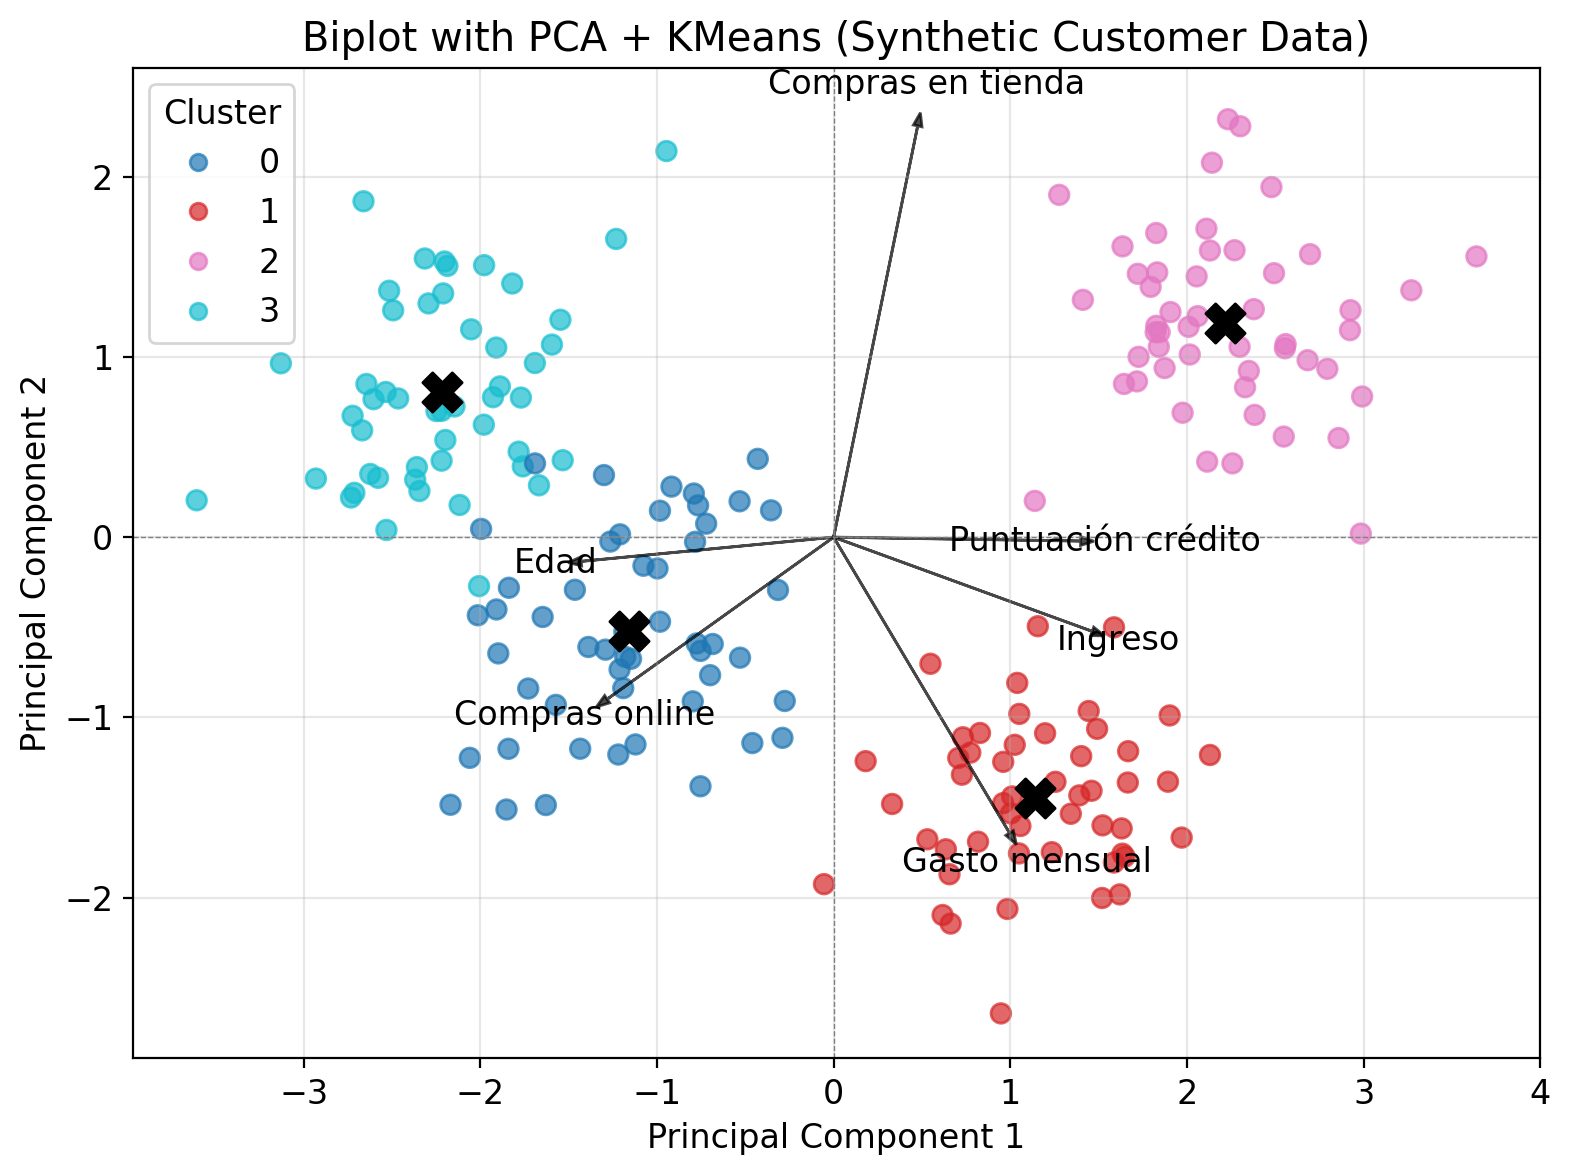

In [6]:
plot_biplot(
    X_pca,
    cluster_labels,
    centroids_pca,
    column_names,
    loadings,
    title="Biplot with PCA + KMeans (Synthetic Customer Data)"
)

## Interpretation of Principal Components

Based on the loadings matrix, we can characterise each principal component:

| Component   | Characterisation |
|-------------|------------------|
| **PC1 (high)** | Customers with high income, high credit score, and high monthly spending. |
| **PC1 (low)**  | Younger customers who shop online with lower income/spending. |
| **PC2 (high)** | Customers who make many in‑store purchases. |
| **PC2 (low)**  | Customers with high overall spending but more online‑oriented. |

These interpretations help segment customers and inform targeted marketing strategies.

## Cluster Characterisation

We can further analyse each cluster by examining the mean feature values in the original space.

Cluster profiles (mean feature values):


,Edad,Ingreso,Gasto mensual,Puntuación crédito,Compras online,Compras en tienda
Cluster,,,,,,
0,-0.848514,-4.269780,2.255684,-7.312853,-3.727536,-2.425647
1,-2.820629,8.895505,4.486968,2.930611,-6.346303,-7.424275
2,-8.539768,7.455900,1.639895,3.956405,-9.469948,9.134468
3,6.402475,-5.704901,-6.180534,-5.500725,-3.674612,0.868137


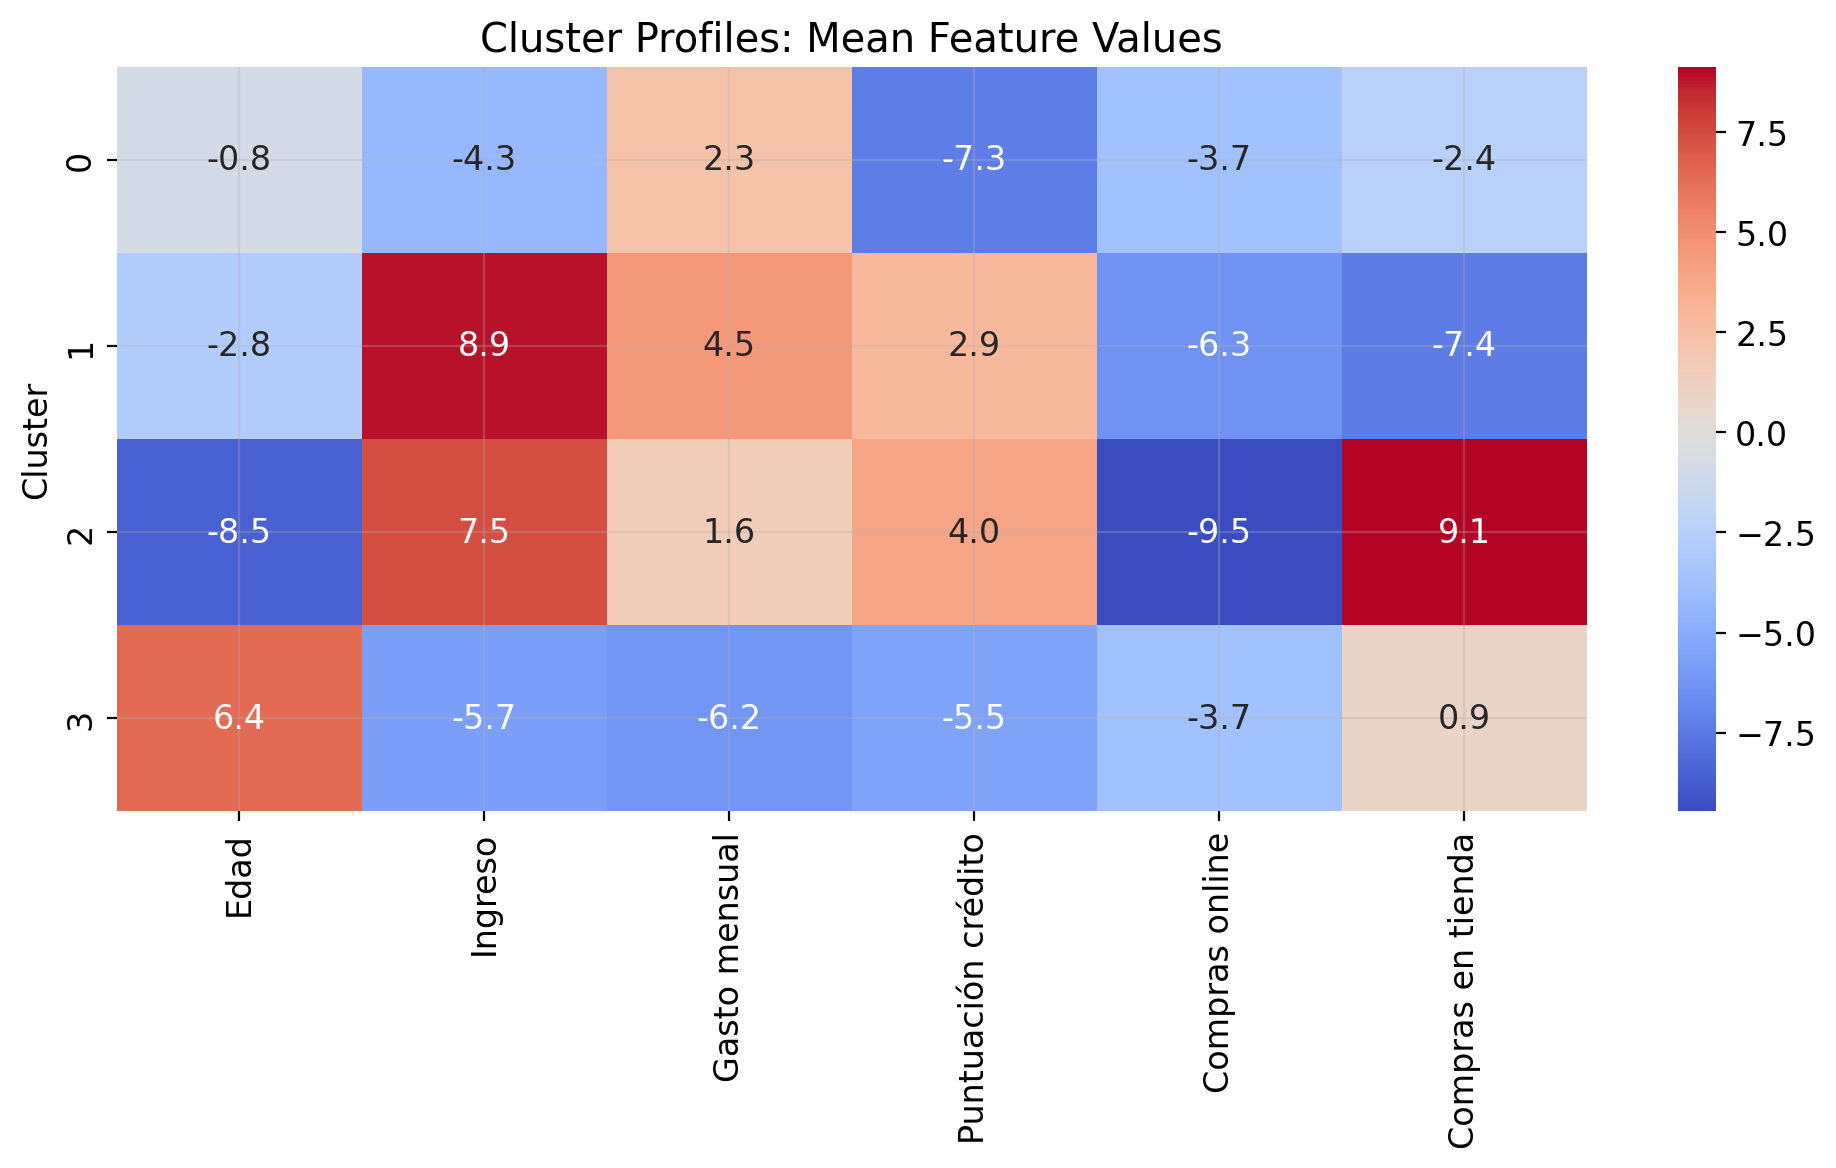

In [7]:
# Add cluster labels to original DataFrame
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

# Compute mean feature values per cluster
cluster_profiles = df_clustered.groupby('Cluster').mean()
print("Cluster profiles (mean feature values):")
display(cluster_profiles)

# Optionally, visualise cluster profiles as a heatmap
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Cluster Profiles: Mean Feature Values")
plt.tight_layout()
plt.show()

## Summary and Next Steps

**Accomplished in this notebook:**

- Generated synthetic customer data with 6 features and 4 underlying segments.
- Standardised the data to ensure equal feature contribution.
- Applied PCA to reduce dimensionality to 2 components, retaining ~78% of variance.
- Performed K‑Means clustering (k=4) on the standardised data.
- Visualised the results in a biplot: points coloured by cluster, centroids, and feature loadings.
- Interpreted principal components and cluster profiles.

**Key insights:**

- PC1 separates customers by income/credit/spending (high vs. low).
- PC2 separates in‑store vs. online shopping behaviour.
- Clusters correspond to distinct customer segments with interpretable characteristics.

**Suggested next steps (critical thinking):**

1. **Optimal number of clusters** – use the elbow method, silhouette score, or gap statistic to determine the best `k`.
2. **Feature engineering** – create new features (e.g., spending ratios, recency) to improve segmentation.
3. **External validation** – if labelled data exists, evaluate cluster purity with metrics like Adjusted Rand Index.
4. **Dimensionality alternatives** – compare PCA with t‑SNE or UMAP for non‑linear visualisation.
5. **Deployment** – wrap the pipeline into a scikit‑learn `Pipeline` for automated clustering of new customers.

This notebook provides a solid foundation for unsupervised customer segmentation with interpretable visualisation.